# Gaia API + spektrų braižymas

Šis notebook sujungia du darbus:
1. **Duomenų gavimas per API** – Gaia@AIP TAP (SQL užklausos) arba SJS (pagal source_id).
2. **Spektrų braižymas** – gaiaxpy `calibrate` + `plot_spectra`.

Galite gauti duomenis dviem būdais:
- **Tiesiog SQL užklausa** – pvz. `SELECT * FROM gaiadr3.xp_continuous_mean_spectrum LIMIT 10` (source_id nereikia).
- **Pagal source_id** – jei norite konkrečių žvaigždžių, naudokite SOURCE_IDS ir SJS (kaip gaia_aip_pavyzdinis).

In [5]:
import io
import os
import ast
from pathlib import Path

from dotenv import load_dotenv
load_dotenv()

import requests
import numpy as np
import pandas as pd
from astropy.io.votable import parse_single_table
from gaiaxpy import calibrate, plot_spectra

## Konfigūracija ir sesija

In [6]:
# Token: https://gaia.aip.de → prisijunkite → paskyra / API token
GAIA_AIP_TOKEN = os.getenv("GAIA_AIP_TOKEN", "")  # arba įrašykite čia: "your-token"
TAP_URL = "https://gaia.aip.de/tap"
OUT = Path("out_gaiaxp_pvz")
OUT.mkdir(exist_ok=True)

if not GAIA_AIP_TOKEN:
    raise RuntimeError("Nustatykite GAIA_AIP_TOKEN. Token gauti: https://gaia.aip.de (prisijungus). Aplinka: export GAIA_AIP_TOKEN=... arba įrašykite šiame langelyje.")

sess = requests.Session()
sess.headers["Authorization"] = (
    GAIA_AIP_TOKEN if GAIA_AIP_TOKEN.startswith("Token ") else f"Token {GAIA_AIP_TOKEN}"
)

## 1. Duomenų gavimas per TAP (SQL)

**Taip – galite vykdyti SQL užklausą ir gauti duomenis iš API.** Source_id nereikia, jei norite tiesiog LIMIT 10 eilučių iš lentelės.

In [8]:
def tap_sync(session: requests.Session, query: str, lang: str = "ADQL") -> pd.DataFrame:
    """Vykdo TAP sync užklausą ir grąžina rezultatą kaip DataFrame."""
    url = f"{TAP_URL}/sync"
    query = query.strip().rstrip(";")
    payload = {"REQUEST": "doQuery", "LANG": lang, "FORMAT": "csv", "QUERY": query}
    r = session.post(url, data=payload, timeout=120)
    r.raise_for_status()
    text = r.text
    ctype = r.headers.get("Content-Type", "").lower()
    if "xml" in ctype or "votable" in ctype or text.lstrip().startswith("<") or "VOTABLE" in text[:200]:
        table = parse_single_table(io.BytesIO(r.content)).to_table(use_names_over_ids=True)
        return table.to_pandas()
    try:
        return pd.read_csv(io.StringIO(text))
    except pd.errors.ParserError:
        return pd.read_csv(io.StringIO(text), comment="#", engine="python")


# Užklausa tiesiog į xp_continuous_mean_spectrum – source_id nereikia
query = """
SELECT TOP 10 * FROM gaiadr3.xp_continuous_mean_spectrum
"""

df_xp = tap_sync(sess, query)
print(f"Gauta eilučių: {len(df_xp)}")
df_xp.head(2)

Gauta eilučių: 10


,source_id,solution_id,bp_basis_function_id,bp_degrees_of_freedom,bp_n_parameters,bp_n_measurements,bp_n_rejected_measurements,bp_standard_deviation,bp_chi_squared,bp_coefficients,...,rp_n_parameters,rp_n_measurements,rp_n_rejected_measurements,rp_standard_deviation,rp_chi_squared,rp_coefficients,rp_coefficient_errors,rp_coefficient_correlations,rp_n_relevant_bases,rp_relative_shrinking
0,4295806720,4545469030156206081,56,931,55,986,10,0.993420,918.788147,"[102.93398893929992, -12.336921213781045, -2.6...",...,55,1164,8,1.021724,1157.706909,"[113.55177710646585, -13.08779641421988, -0.16...","[0.5033709, 0.47430962, 0.4662404, 0.50047135,...","[0.07016296, 0.10792179, 0.0137324175, 0.02843...",2,0.999631
1,38655544960,4545469030156206081,56,887,55,942,2,1.044791,968.239014,"[2464.694270072498, -16.53425962660646, -103.7...",...,55,1101,9,1.045385,1143.099854,"[3313.824932990714, -268.99637647987817, 2.659...","[2.2215922, 2.031011, 2.0189552, 2.2340422, 2....","[-0.044290394, 0.18274502, 0.1149835, -0.01562...",46,1.000000


## Gauname žvaigždžių spiečiaus duomenis

Užklausa: žvaigždės iš sferos (CIRCLE), su parallax > 5, su BP/RP spektrų koeficientais.

In [13]:
query_cluster = """
SELECT
  gs.source_id,
  gs.ra, gs.dec,
  gs.parallax, gs.pmra, gs.pmdec,
  gs.phot_g_mean_mag, gs.phot_bp_mean_mag, gs.phot_rp_mean_mag,
  gs.bp_rp, gs.ruwe,

  xp.bp_coefficients,
  xp.bp_coefficient_errors,
  xp.rp_coefficients,
  xp.rp_coefficient_errors

FROM gaiadr3.gaia_source AS gs
JOIN gaiadr3.xp_continuous_mean_spectrum AS xp
  ON gs.source_id = xp.source_id

WHERE 1 = CONTAINS(
  POINT('ICRS', gs.ra, gs.dec),
  CIRCLE('ICRS', 66.5, 16.0, 8.0)
)
AND gs.parallax > 5
"""

tdata = tap_sync(sess, query_cluster)
print(f"Gauta eilučių: {len(tdata)}")
tdata.head()

Gauta eilučių: 8016


,source_id,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,ruwe,bp_coefficients,bp_coefficient_errors,rp_coefficients,rp_coefficient_errors
0,3287029529231775616,65.740084,8.066118,7.111314,-14.885536,-16.728461,13.966544,14.925832,12.999740,1.926092,1.000643,"[2164.8890412037645, 318.5789033415795, -70.55...","[2.9080007, 2.3798878, 2.6899483, 2.553109, 2....","[4911.1021779330285, 299.12578138475266, 199.2...","[2.6193068, 2.3089116, 2.3730237, 2.6594007, 2..."
1,3287041688283537408,66.313525,8.048835,29.676405,139.999537,3.359305,11.564099,12.865689,10.431300,2.434389,26.788876,"[14181.854692544039, 2139.7871194635336, 39.96...","[24.948126, 23.70778, 27.61808, 19.45911, 20.4...","[53009.25141475564, 10815.672682557604, 2995.4...","[18.220364, 17.04381, 17.49873, 18.501205, 19...."
2,3287041726938931968,66.321206,8.067751,28.883622,146.642040,2.556871,13.417475,15.072522,12.181408,2.891114,1.312481,"[1843.1017636367624, 320.74240776050937, 88.92...","[3.3207078, 2.7300682, 3.1336133, 2.892063, 2....","[10584.420667031405, 3300.970579942612, 442.40...","[5.2497096, 4.2757597, 4.7659397, 5.578678, 5...."
3,3287054508761613952,66.001688,8.162482,6.113410,26.091301,26.415460,12.584616,13.178671,11.853700,1.324971,1.812112,"[10074.93189101969, 56.785720932839496, -467.8...","[7.2259684, 6.3350825, 6.4603424, 6.443527, 6....","[13906.984845223496, -1041.8600463161565, 40.8...","[4.115976, 3.745807, 3.7889047, 4.352234, 3.96..."
4,3287062888241894400,66.079520,8.273601,6.455839,26.244188,-12.906427,17.027321,18.781984,15.777832,3.004152,0.900336,"[62.277373070320316, 11.63228289839473, 1.2803...","[0.5419288, 0.50729626, 0.5349588, 0.50483376,...","[385.6596698589611, 125.80248713391859, 12.427...","[0.70958215, 0.6263804, 0.6697484, 0.74071, 0...."


In [18]:
query_cluster = """
select count(distinct source_id) from gaiadr3.xp_sampled_mean_spectrum
"""

tdata = tap_sync(sess, query_cluster)
print(f"Gauta eilučių: {len(tdata)}")
tdata.head()

HTTPError: 500 Server Error: Internal Server Error for url: https://gaia.aip.de/tap/sync

## 2. Paruošimas gaiaxpy (masyvai, ne stringai)

GaiaXPy tikisi, kad koeficientų stulpeliai būtų numpy masyvai. Jei iš TAP gaunate stringus (pvz. CSV), juos reikia konvertuoti.

In [9]:
def ensure_arrays(df: pd.DataFrame) -> pd.DataFrame:
    """Koeficientų ir koreliacijų stulpelius paverčia į numpy masyvus."""
    cols = [
        "bp_coefficients", "bp_coefficient_errors", "bp_coefficient_correlations",
        "rp_coefficients", "rp_coefficient_errors", "rp_coefficient_correlations",
    ]
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            continue
        def to_array(x):
            if isinstance(x, str):
                return np.array(ast.literal_eval(x), dtype=float)
            return np.asarray(x, dtype=float)
        out[c] = out[c].apply(to_array)
    return out

df_ready = ensure_arrays(df_xp)
print("Paruošta braižymui.")

Paruošta braižymui.


## 3. Kalibracija ir spektrų braižymas

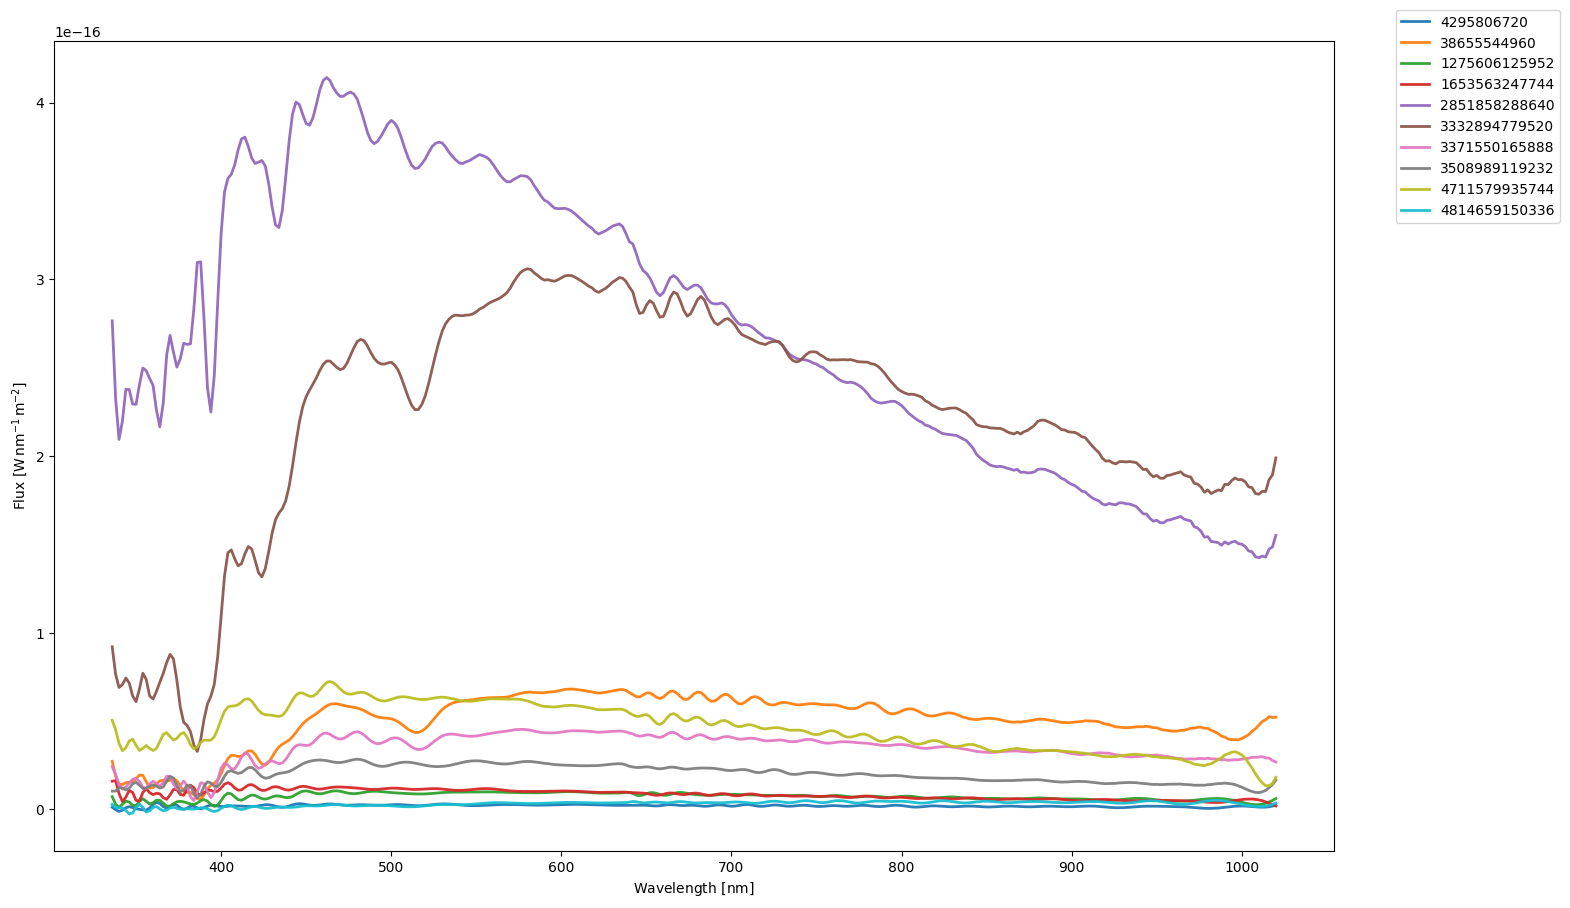

In [11]:
# Nenaudoti LaTeX (kad išvengtume FileNotFoundError: 'latex')
import matplotlib
matplotlib.rcParams['text.usetex'] = False

# Kalibruoti ir gauti sampling (bangų ilgių tinklelį)
calibrated_spectrum, sampling = calibrate(
    df_ready,
    save_file=False,
    with_correlation=False,
)

# Braižyti visus spektrus iš df_ready (iki 10)
plot_spectra(
    calibrated_spectrum,
    sampling=sampling,
    legend=True,
    multi=True,
)

---
## Pasirinktinai: viena žvaigždė pagal source_id

Jei norite braižyti tik vieną žvaigždę pagal `source_id`, išfiltruokite DataFrame ir braižykite:

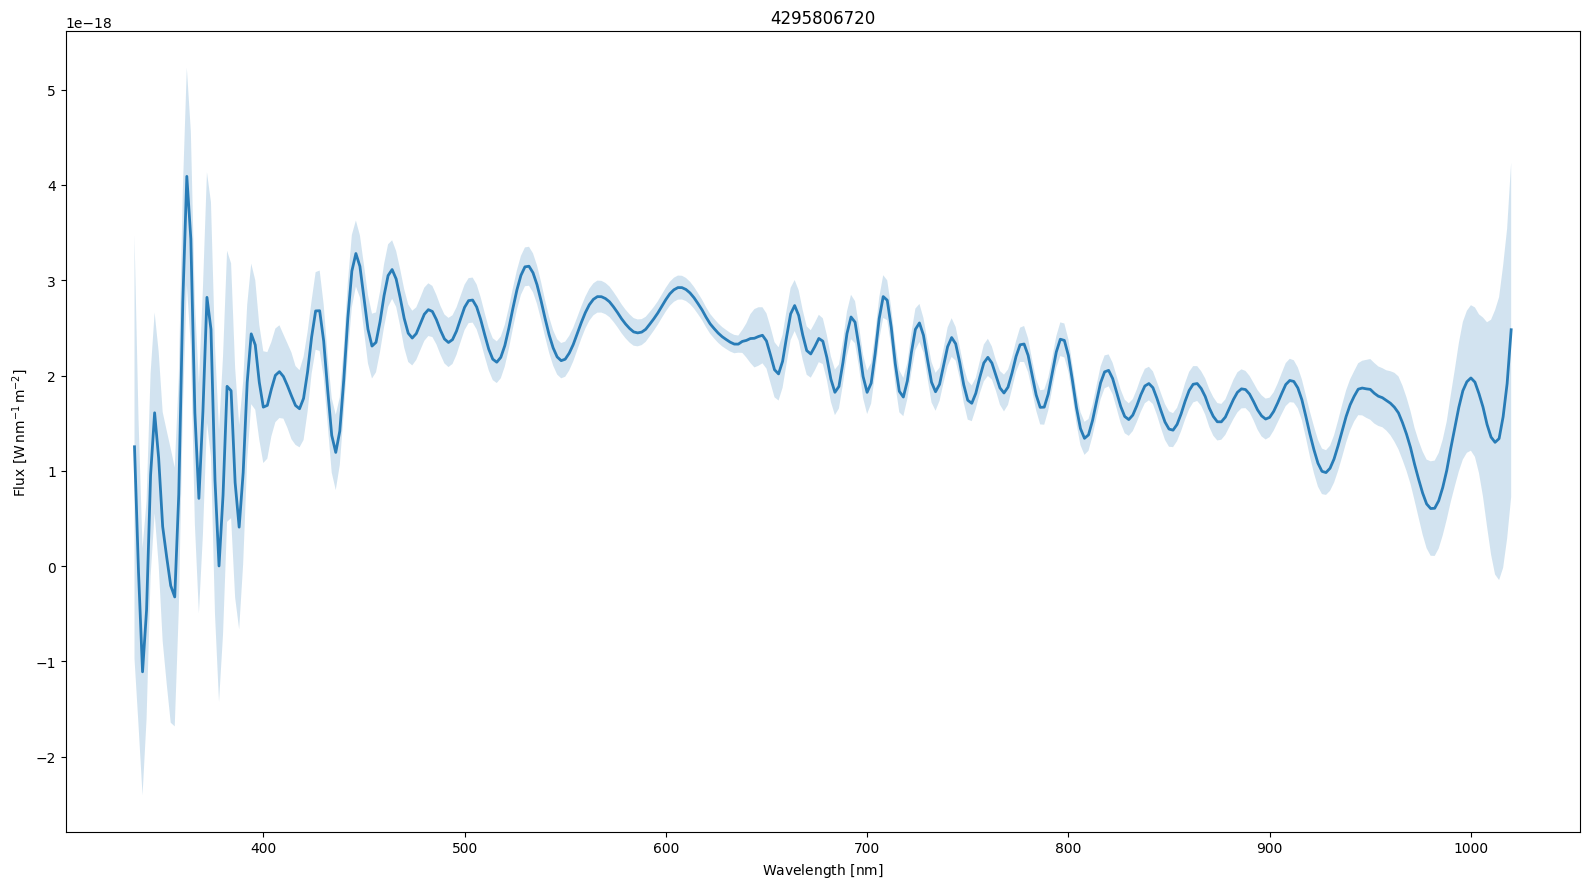

In [12]:
import matplotlib
matplotlib.rcParams['text.usetex'] = False

# Pavyzdys: pirmoji žvaigždė iš gautų duomenų
source_id = df_ready["source_id"].iloc[0]
one_star = ensure_arrays(df_ready[df_ready["source_id"] == source_id].copy())

cal_one, sampling_one = calibrate(one_star, save_file=False, with_correlation=False)
plot_spectra(cal_one, sampling=sampling_one, legend=False, multi=False)